In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('weight-height.csv')

In [3]:
df.sample(5)

,Gender,Height,Weight
8617,Female,61.979324,137.083428
4386,Male,62.348318,150.721988
7673,Female,66.234447,147.553007
8672,Female,67.415348,150.498251
5947,Female,65.531554,158.598828


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height'>

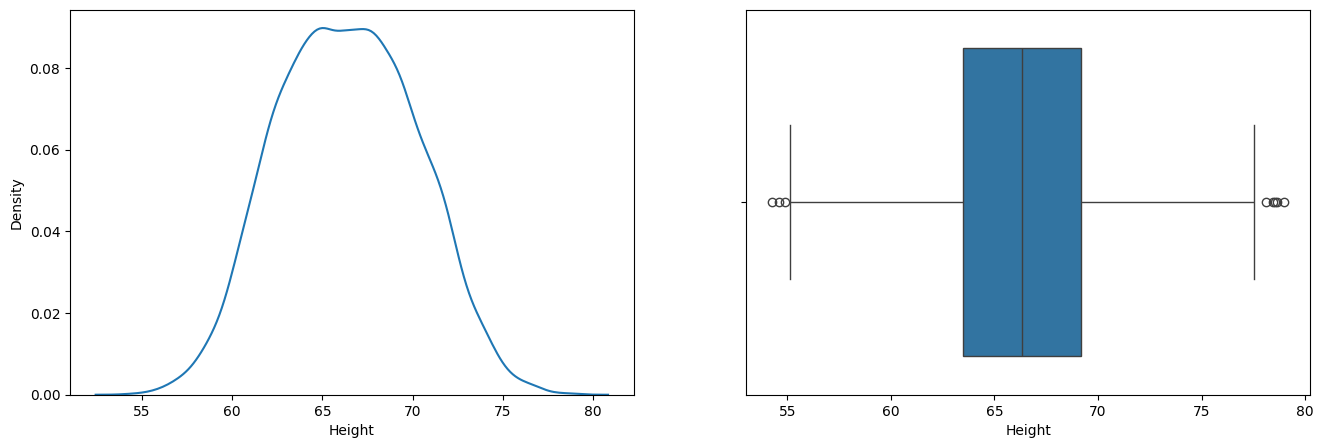

In [7]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['Height'],ax=ax1)
sns.boxplot(x=df['Height'],ax=ax2)

<p>Visible outliers in boxplot.</p>

In [8]:
up_lim=df['Height'].quantile(0.99)
up_lim

np.float64(74.7857900583366)

In [9]:
low_lim=df['Height'].quantile(0.01)
low_lim

np.float64(58.13441158671655)

<h1>Detecting Outliers</h1>

In [10]:
df[(df['Height']>74.78) | (df['Height']<58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


<h3>Trimming</h3>

In [11]:
new_df=df[(df['Height']<=74.78) & (df['Height']>=58.13)]

In [12]:
new_df.shape

(9799, 3)

In [13]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

<Axes: xlabel='Height'>

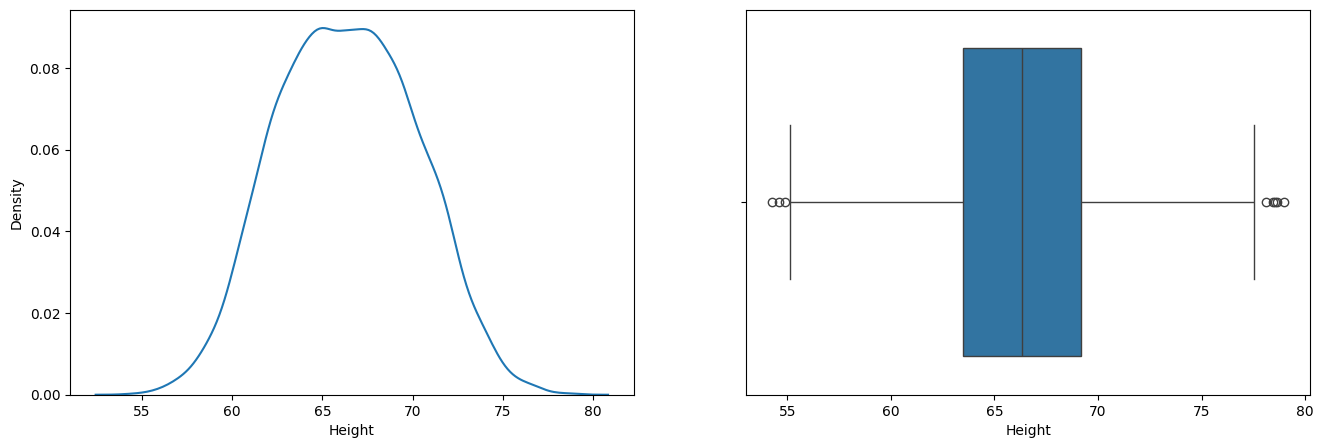

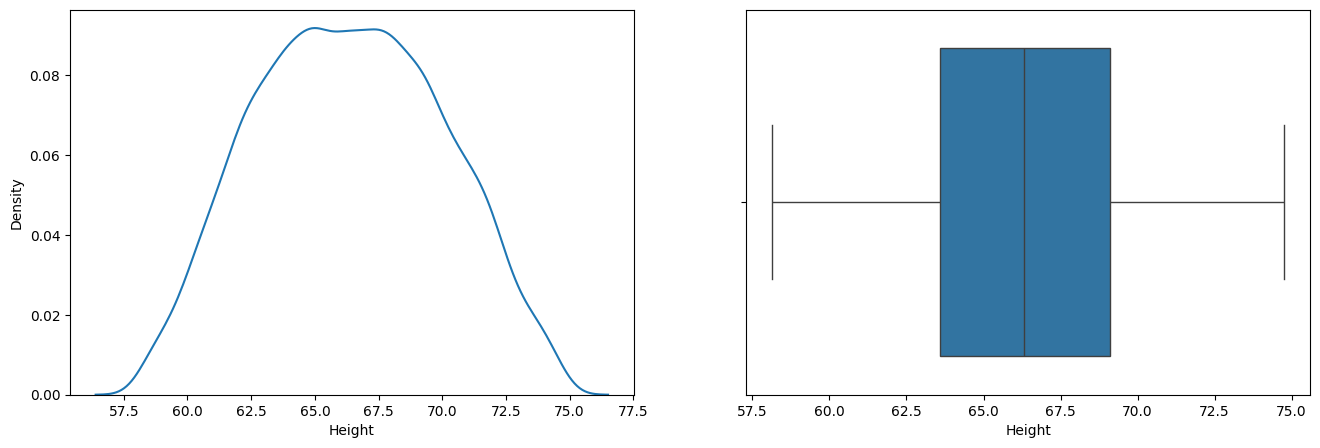

In [15]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['Height'],ax=ax1)
sns.boxplot(x=df['Height'],ax=ax2)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(new_df['Height'],ax=ax1)
sns.boxplot(x=new_df['Height'],ax=ax2)

<p>Slight change in distribution and noticable outlier deduction in boxplot.</p>

<h3>Capping (Winsorization)</h3>

In [16]:
new_df_cap=df.copy()

new_df_cap['Height']=np.where(df["Height"]>up_lim,up_lim,
                              np.where(df['Height']<low_lim,low_lim,df['Height'])
                             )

In [17]:
new_df_cap.shape

(10000, 3)

In [19]:
new_df_cap['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height'>

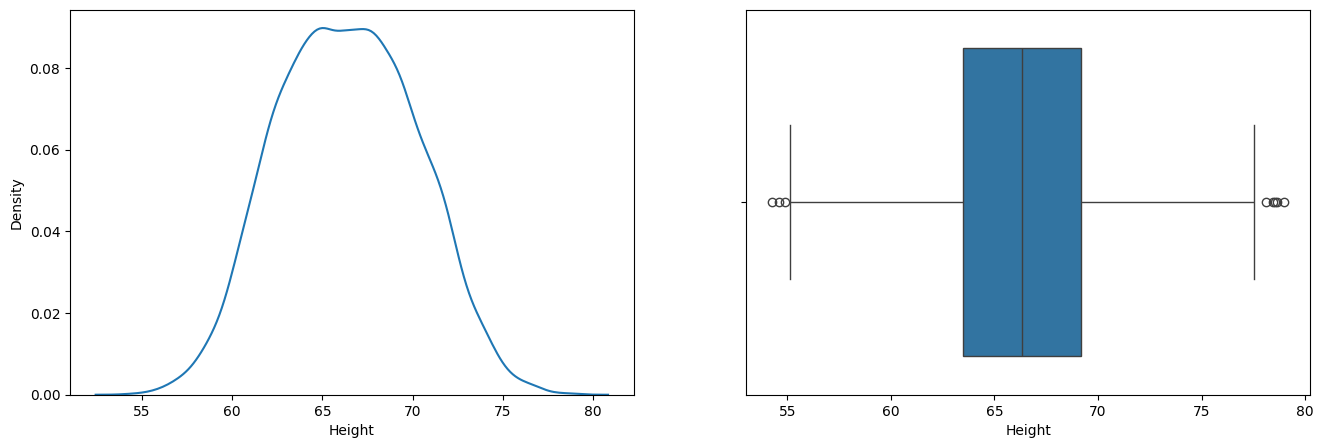

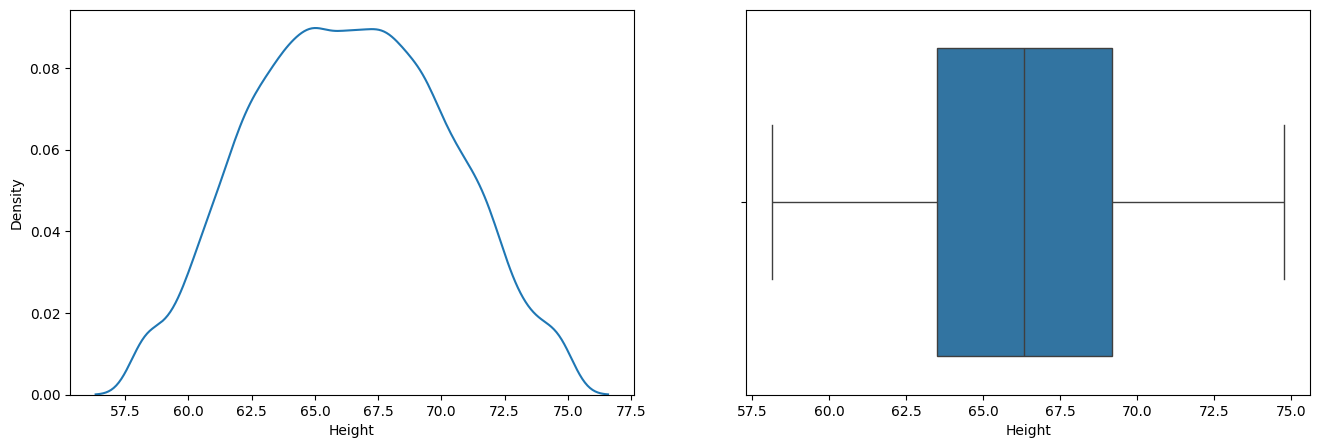

In [20]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['Height'],ax=ax1)
sns.boxplot(x=df['Height'],ax=ax2)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(new_df_cap['Height'],ax=ax1)
sns.boxplot(x=new_df_cap['Height'],ax=ax2)

<p>Slight change in distribution and noticable outlier deduction in boxplot.</p>